In [58]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [59]:
#Bounding Box of Egypt
min_lat = 22.0
max_lat = 31.58568
min_lon = 24.70007
max_lon = 36.86623

In [60]:
ds = xr.open_dataset('cru_ts4.07.1901.2022.pre.dat.nc')

In [61]:
ds

<xarray.Dataset>
Dimensions:  (lon: 720, lat: 360, time: 1464)
Coordinates:
  * lon      (lon) float32 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
  * lat      (lat) float32 -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
  * time     (time) datetime64[ns] 1901-01-16 1901-02-15 ... 2022-12-16
Data variables:
    pre      (time, lat, lon) float32 ...
    stn      (time, lat, lon) float64 ...
Attributes:
    Conventions:  CF-1.4
    title:        CRU TS4.07 Precipitation
    institution:  Data held at British Atmospheric Data Centre, RAL, UK.
    source:       Run ID = 2304141047. Data generated from:pre.2304141039.dtb
    history:      Fri 14 Apr 12:49:03 BST 2023 : User f098 : Program makegrid...
    references:   Information on the data is available at http://badc.nerc.ac...
    comment:      Access to these data is available to any registered CEDA user.
    contact:      support@ceda.ac.uk

In [62]:
#Subset Egypt
ds_egypt = ds.sel(lat=slice(min_lat, max_lat),
                  lon=slice(min_lon, max_lon),
                 time=slice('1990-01-01','2020-12-31'))
ds_egypt

<xarray.Dataset>
Dimensions:  (lon: 25, lat: 19, time: 372)
Coordinates:
  * lon      (lon) float32 24.75 25.25 25.75 26.25 ... 35.25 35.75 36.25 36.75
  * lat      (lat) float32 22.25 22.75 23.25 23.75 ... 29.75 30.25 30.75 31.25
  * time     (time) datetime64[ns] 1990-01-16 1990-02-15 ... 2020-12-16
Data variables:
    pre      (time, lat, lon) float32 ...
    stn      (time, lat, lon) float64 ...
Attributes:
    Conventions:  CF-1.4
    title:        CRU TS4.07 Precipitation
    institution:  Data held at British Atmospheric Data Centre, RAL, UK.
    source:       Run ID = 2304141047. Data generated from:pre.2304141039.dtb
    history:      Fri 14 Apr 12:49:03 BST 2023 : User f098 : Program makegrid...
    references:   Information on the data is available at http://badc.nerc.ac...
    comment:      Access to these data is available to any registered CEDA user.
    contact:      support@ceda.ac.uk

In [63]:
# Calculate mean precipitation over 1990-2020
mean_precip = ds_egypt['pre'].mean(dim='time')

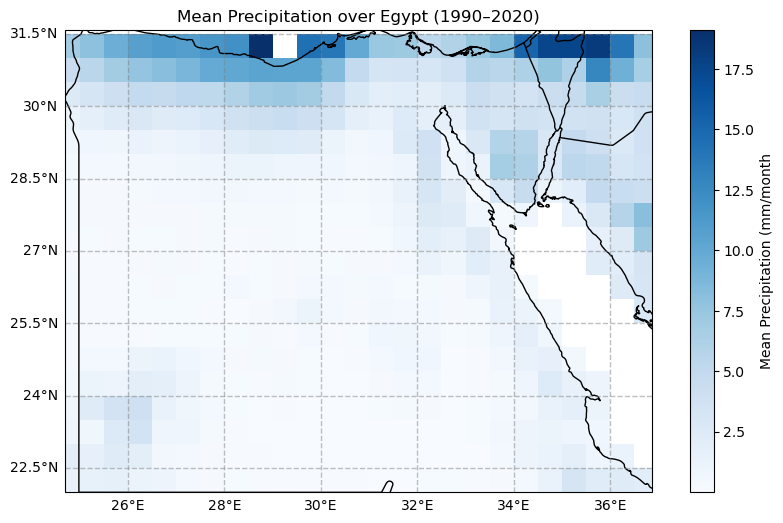

In [99]:
plt.figure(figsize=(10,6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Set Egypt bounding box
ax.set_extent([24.70, 36.86, 22.0, 31.58], crs=ccrs.PlateCarree())

# Plot mean precipitation
mean_precip.plot(
    cmap='Blues',
    ax=ax,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'Mean Precipitation (mm/month'})
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
gl = ax.gridlines(draw_labels=True, linewidth=1,
                  color='gray', alpha=0.5, linestyle='--')

gl.top_labels = False
gl.right_labels = False
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
# Axis labels
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.title('Mean Precipitation over Egypt (1990–2020)')
plt.show()

In [65]:
# Calculating annual mean precipitation over 1990-2020
annual_precip = ds_egypt['pre'].groupby ('time.year').sum(dim='time')
annual_precip

<xarray.DataArray 'pre' (year: 31, lat: 19, lon: 25)>
array([[[ 16.300001,  18.1     ,  20.1     , ...,  19.2     ,
          18.7     ,  19.6     ],
        [ 21.6     ,  18.5     ,  26.3     , ...,   7.2     ,
          10.9     ,   0.      ],
        [ 10.000001,   9.400001,  31.      , ...,   9.      ,
           0.      ,   0.      ],
        ...,
        [ 34.1     ,  42.9     ,  54.399998, ...,  85.69999 ,
          60.3     ,  62.000004],
        [ 57.299995,  71.1     ,  88.700005, ..., 148.70003 ,
         110.100006,  79.4     ],
        [ 88.8     , 101.899994, 124.2     , ..., 216.09999 ,
         159.20001 ,  92.      ]],

       [[ 16.300001,  18.1     ,  20.1     , ...,  19.7     ,
          19.3     ,  18.4     ],
        [ 21.6     ,  18.5     ,  26.3     , ...,   6.200001,
           9.8     ,   0.      ],
        [ 10.000001,   9.400001,  31.2     , ...,   4.9     ,
           0.      ,   0.      ],
...
        [ 25.600002,  33.9     ,  42.      , ...,  85.5     ,
          57.2     ,  58.3     ],
        [ 45.700005,  59.100002,  73.600006, ..., 171.20001 ,
         126.00001 ,  87.8     ],
        [ 71.799995,  85.6     , 103.799995, ..., 241.60002 ,
         188.09999 , 104.399994]],

       [[ 16.800001,  18.6     ,  20.400002, ...,  33.399998,
          37.9     ,  34.9     ],
        [ 22.800001,  19.300001,  27.1     , ...,  14.8     ,
          20.8     ,   0.      ],
        [ 10.800001,  10.000001,  32.6     , ...,  10.7     ,
           0.      ,   0.      ],
        ...,
        [ 32.600002,  44.700005,  65.      , ..., 109.99999 ,
          72.9     ,  76.5     ],
        [ 55.7     ,  72.600006, 100.9     , ..., 219.1     ,
         156.90001 , 111.100006],
        [ 86.3     , 102.700005, 133.20001 , ..., 312.1     ,
         233.8     , 129.8     ]]], dtype=float32)
Coordinates:
  * lon      (lon) float32 24.75 25.25 25.75 26.25 ... 35.25 35.75 36.25 36.75
  * lat      (lat) float32 22.25 22.75 23.25 23.75 ... 29.75 30.25 30.75 31.25
  * year     (year) int64 1990 1991 1992 1993 1994 ... 2016 2017 2018 2019 2020
Attributes:
    long_name:                   precipitation
    units:                       mm/month
    correlation_decay_distance:  450.0

In [66]:
annual_mean_precip=annual_precip.mean(dim='year')

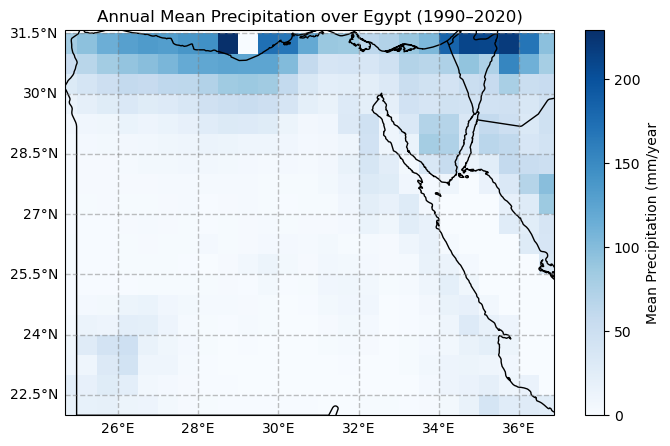

In [124]:
# Plot the annual meanmap
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

plt.figure(figsize=(8,5))
ax = plt.axes(projection=ccrs.PlateCarree())

# Set Egypt bounding box
ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())

# Plot mean precipitation
annual_mean_precip.plot(
    cmap='Blues',
    ax=ax,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'Mean Precipitation (mm/year'}
)

# Add coastlines and borders
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)

# Add gridlines with labels
gl = ax.gridlines(draw_labels=True, linewidth=1,
                  color='gray', alpha=0.5, linestyle='--')

gl.top_labels = False
gl.right_labels = False
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
# Axis labels
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.title('Annual Mean Precipitation over Egypt (1990–2020)')
plt.show()

In [71]:
annual_mean_series = annual_precip.mean(dim=['lat','lon'])  
annual_mean_series

<xarray.DataArray 'pre' (year: 31)>
array([27.679789, 40.949684, 32.213898, 27.51895 , 40.861473, 17.082315,
       21.652843, 28.525265, 24.806948, 15.44    , 29.103157, 19.053896,
       26.894947, 21.832212, 24.358948, 22.892   , 19.745264, 19.553055,
       20.462738, 14.244842, 17.090105, 21.251793, 22.400843, 26.766735,
       27.704422, 25.377472, 21.198105, 14.279578, 37.938526, 28.250525,
       31.893261], dtype=float32)
Coordinates:
  * year     (year) int64 1990 1991 1992 1993 1994 ... 2016 2017 2018 2019 2020

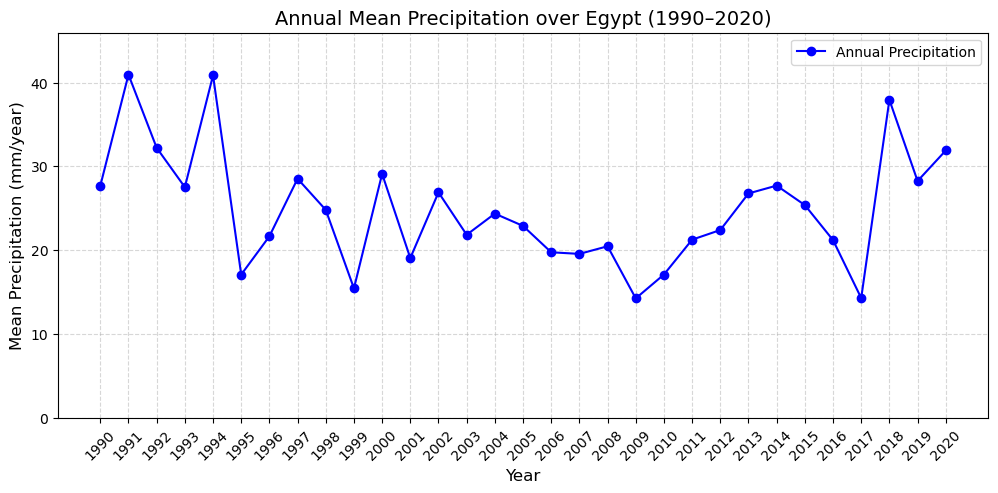

In [117]:
years = annual_mean_series['year'].values
precip_values = annual_mean_series.values

plt.figure(figsize=(12,5))

# Plot the annual mean precipitation year by year
plt.plot(years, precip_values, marker='o', linestyle='-', color='blue', label='Annual Precipitation')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Mean Precipitation (mm/year)', fontsize=12)
plt.title('Annual Mean Precipitation over Egypt (1990–2020)', fontsize=14)

# Show all years on x-axis
plt.xticks(years, years, rotation=45)

#set y-axis limits to highlight variations
plt.ylim(0, max(precip_values)+5)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

In [118]:
years = annual_mean_series.year.values
values = annual_mean_series.values

In [119]:
from scipy.stats import linregress

In [77]:
slope, intercept, r_value, p_value, std_err = linregress(years, values)

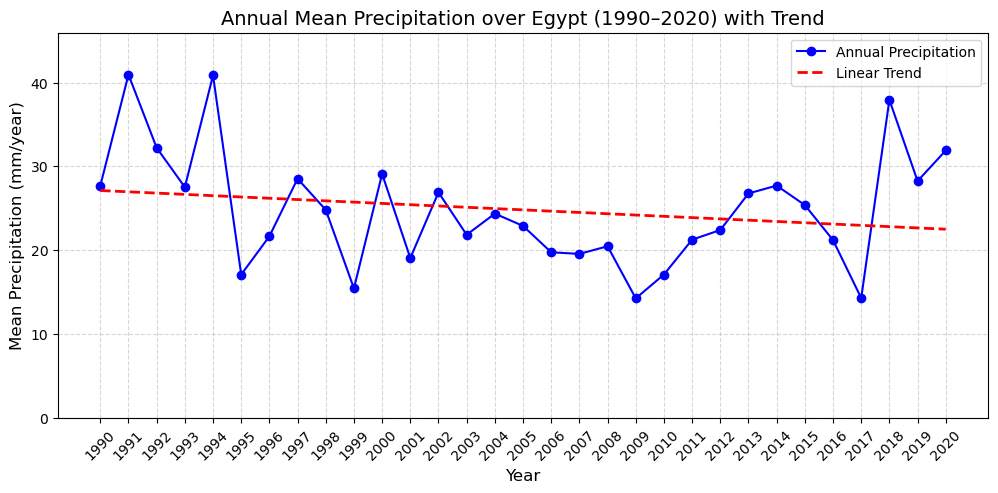

Slope of trend: -0.1539 mm/year


In [85]:
years = annual_mean_series['year'].values
precip_values = annual_mean_series.values

# Calculate linear trend
z = np.polyfit(years, precip_values, 1)          # slope and intercept
trend_line = np.poly1d(z)(years)                # linear trend values

plt.figure(figsize=(12,5))

# Plot annual mean precipitation
plt.plot(years, precip_values, marker='o', linestyle='-', color='blue', label='Annual Precipitation')

# Plot linear trend line
plt.plot(years, trend_line, color='red', linestyle='--', linewidth=2, label='Linear Trend')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Mean Precipitation (mm/year)', fontsize=12)
plt.title('Annual Mean Precipitation over Egypt (1990–2020) with Trend', fontsize=14)

# Show all years on x-axis
plt.xticks(years, years, rotation=45)

# Optional: set y-axis limits
plt.ylim(0, max(precip_values)+5)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

# Print slope
print(f"Slope of trend: {z[0]:.4f} mm/year")

In [90]:
print(f"Slope: {slope:.4f} mm/year")
print(f"R value: {r_value:.4f}")
print(f"P value: {p_value:.4f}")

Slope: -0.1539 mm/year
R value: -0.2005
P value: 0.2794


In [92]:
std_precip = np.std(precip_values)
print("Standard Deviation:", std_precip)

Standard Deviation: 6.865476


In [96]:
decade1 = annual_precip.sel(year=slice(1990, 1999)).mean(dim='year')
decade2 = annual_precip.sel(year=slice(2010, 2020)).mean(dim='year')
difference = decade2 - decade1

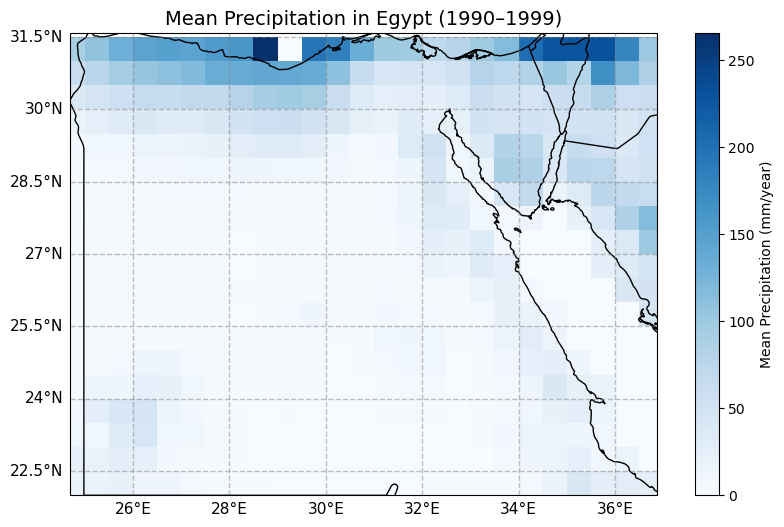

In [98]:


plt.figure(figsize=(10,6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())
decade1_mean.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='Blues',
    cbar_kwargs={'label': 'Mean Precipitation (mm/year)'})
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
gl = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 11}
gl.ylabel_style = {'size': 11}
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
plt.title('Mean Precipitation in Egypt (1990–1999)', fontsize=14)
plt.show()

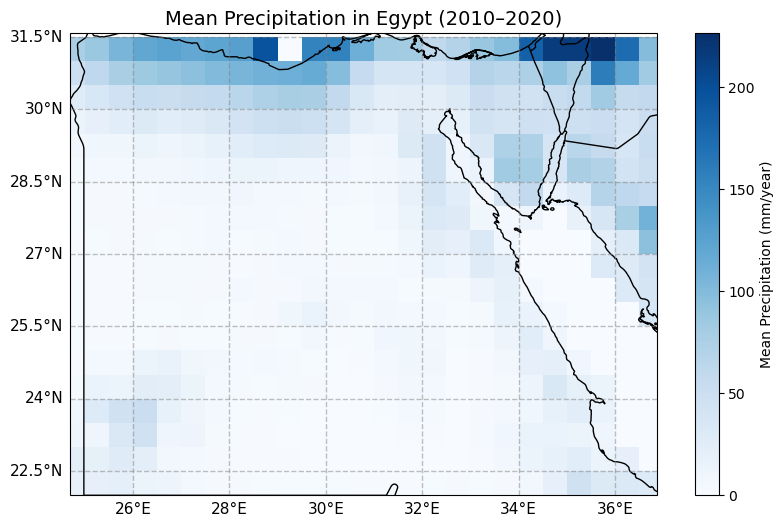

In [115]:
plt.figure(figsize=(10,6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())

# Plot mean precipitation
decade2.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='Blues',
    cbar_kwargs={'label': 'Mean Precipitation (mm/year)'})
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
gl = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 11}
gl.ylabel_style = {'size': 11}
ax.set_xlabel('Longitude', fontsize=8)
ax.set_ylabel('Latitude', fontsize=8)
plt.title('Mean Precipitation in Egypt (2010–2020)', fontsize=14)
plt.show()


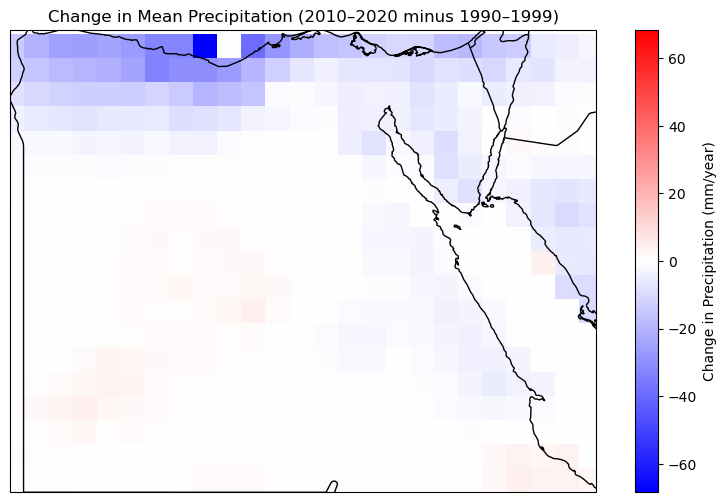

In [114]:
# Plot difference map (2010–2020 minus 1990–1999)
plt.figure(figsize=(10,6))
ax = plt.axes(projection=ccrs.PlateCarree())
difference.plot(
    ax=ax, transform=ccrs.PlateCarree(), cmap="bwr", cbar_kwargs={"label": "Change in Precipitation (mm/year)"})
ax.coastlines()
ax.add_feature(cfeature.BORDERS)
ax.set_extent([min_lon, max_lon, min_lat, max_lat])
ax.grid('True')
plt.title("Change in Mean Precipitation (2010–2020 minus 1990–1999)")
plt.show()

In [105]:
print(difference.min().values)
print(difference.max().values)

-68.38545227050781
4.297279357910156


In [110]:
diff_df = difference.to_dataframe().reset_index()
diff_df = diff_df.dropna()
top_increase = diff_df.nlargest(5, 'pre')
top_decrease = diff_df.nsmallest(5, 'pre')
print("Top 5 Increases:")
print(top_increase[['lat', 'lon', 'pre']])
print("\nTop 5 Decreases:")
print(top_decrease[['lat', 'lon', 'pre']])

Top 5 Increases:
       lat    lon       pre
78   23.75  26.25  4.297279
247  26.75  35.75  4.080910
185  25.75  29.75  3.842727
21   22.25  35.25  3.795456
104  24.25  26.75  3.598185

Top 5 Decreases:
       lat    lon        pre
458  31.25  28.75 -68.385452
460  31.25  29.75 -39.287277
431  30.75  27.75 -33.452721
457  31.25  28.25 -32.843636
456  31.25  27.75 -32.699097


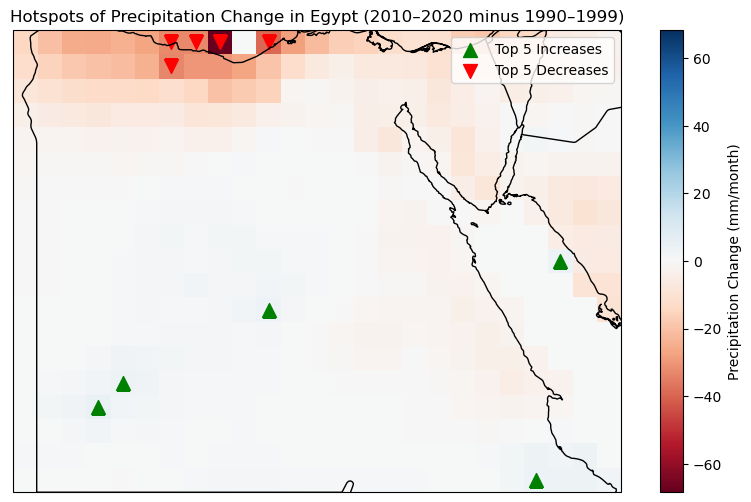

In [111]:
plt.figure(figsize=(10,6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Plot difference map
difference.plot(
    cmap='RdBu',
    ax=ax,
    cbar_kwargs={'label': 'Precipitation Change (mm/month)'})
# Plot top 5 increases (green)
ax.scatter(top5_inc_lon, top5_inc_lat, color='green', s=100, marker='^', label='Top 5 Increases')
# Plot top 5 decreases (red)
ax.scatter(top5_dec_lon, top5_dec_lat, color='red', s=100, marker='v', label='Top 5 Decreases')

ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)

plt.title('Hotspots of Precipitation Change in Egypt (2010–2020 minus 1990–1999)')
plt.legend()
plt.show()

In [112]:
percentile_90 = annual_precip.quantile(0.9, dim='year')
wet_years = annual_precip > percentile_90
wet_frequency = wet_years.sum(dim='year')

<xarray.DataArray 'pre' (lat: 19, lon: 25)>
array([[1, 1, 1, 1, 1, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
        3, 3, 3],
       [1, 1, 1, 1, 0, 2, 3, 3, 2, 2, 3, 2, 2, 3, 2, 2, 3, 3, 3, 3, 3, 3,
        3, 3, 0],
       [1, 1, 1, 1, 1, 1, 2, 3, 3, 3, 3, 3, 2, 2, 3, 3, 2, 2, 2, 2, 2, 3,
        3, 0, 0],
       [1, 1, 2, 3, 2, 3, 3, 2, 3, 3, 2, 2, 3, 3, 3, 3, 2, 3, 3, 2, 3, 2,
        3, 0, 0],
       [2, 2, 3, 3, 3, 3, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
        3, 0, 0],
       [2, 2, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3,
        0, 0, 0],
       [3, 2, 3, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0,
        0, 0, 0],
       [3, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0,
        0, 0, 3],
       [3, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0, 0,
        0, 3, 3],
       [3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 0, 0, 0,
        3, 3, 3],
       [3, 3, 3, 3, 3, 3, 3, 3, 3, 3

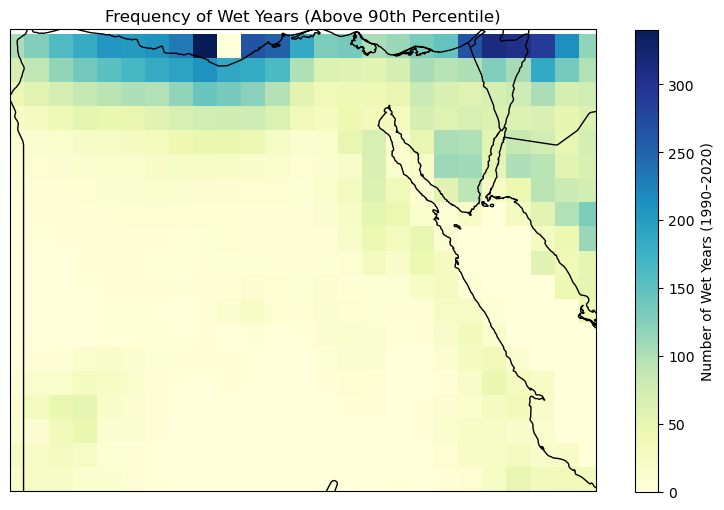

In [113]:
plt.figure(figsize=(10,6))
ax = plt.axes(projection=ccrs.PlateCarree())

percentile_90.plot(
    ax=ax, transform=ccrs.PlateCarree(), cmap="YlGnBu", cbar_kwargs={"label": "Number of Wet Years (1990–2020)"}
)

ax.coastlines()
ax.add_feature(cfeature.BORDERS)
ax.set_extent([min_lon, max_lon, min_lat, max_lat])
plt.title("Frequency of Wet Years (Above 90th Percentile)")
plt.show()